# Privacy-Preserving Federated Network Intrusion Detection System

# Notebook 02 - Exploratory Data Analysis (EDA)

## Objectives

- Merge all CICIDS2017 datasets
- Explore feature distributions
- Analyze class imbalance
- Detect missing values and duplicates
- Identify outliers
- Study feature correlations
- Generate report-ready visualizations

In [1]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# =====================================================
# PROJECT CONFIGURATION
# =====================================================

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "CICIDS2017"

RESULTS_PATH = PROJECT_ROOT / "results"

FIGURES_PATH = RESULTS_PATH / "figures"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(RAW_DATA_PATH)

c:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\data\raw\CICIDS2017


In [3]:
# =====================================================
# LOAD & MERGE DATASET
# =====================================================

csv_files = sorted(RAW_DATA_PATH.glob("*.csv"))

dataframes = []

for file in csv_files:

    print(f"Loading {file.name}")

    df = pd.read_csv(file, low_memory=False)

    dataframes.append(df)

merged_df = pd.concat(
    dataframes,
    ignore_index=True
)

print("\nDataset Merged Successfully")
print("Shape :", merged_df.shape)

Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading Monday-WorkingHours.pcap_ISCX.csv
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading Tuesday-WorkingHours.pcap_ISCX.csv
Loading Wednesday-workingHours.pcap_ISCX.csv

Dataset Merged Successfully
Shape : (2830743, 79)


In [4]:
# =====================================================
# DATASET OVERVIEW
# =====================================================

print(f"Rows : {merged_df.shape[0]:,}")
print(f"Columns : {merged_df.shape[1]}")

merged_df.head()

Rows : 2,830,743
Columns : 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
# =====================================================
# DATASET INFORMATION
# =====================================================

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

merged_df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max

In [6]:
# =====================================================
# BASIC STATISTICS
# =====================================================

merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


In [7]:
# =====================================================
# MISSING VALUES
# =====================================================

missing_values = (
    merged_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values = missing_values[missing_values > 0]

missing_values.to_frame(name="Missing Values")

,Missing Values
Flow Bytes/s,1358


In [8]:
# =====================================================
# DUPLICATE ROWS
# =====================================================

duplicate_rows = merged_df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows:,}")

Duplicate Rows: 308,381


In [9]:
# =====================================================
# CLASS DISTRIBUTION
# =====================================================

label_column = merged_df.columns[-1]

class_distribution = (
    merged_df[label_column]
    .value_counts()
)

class_distribution

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

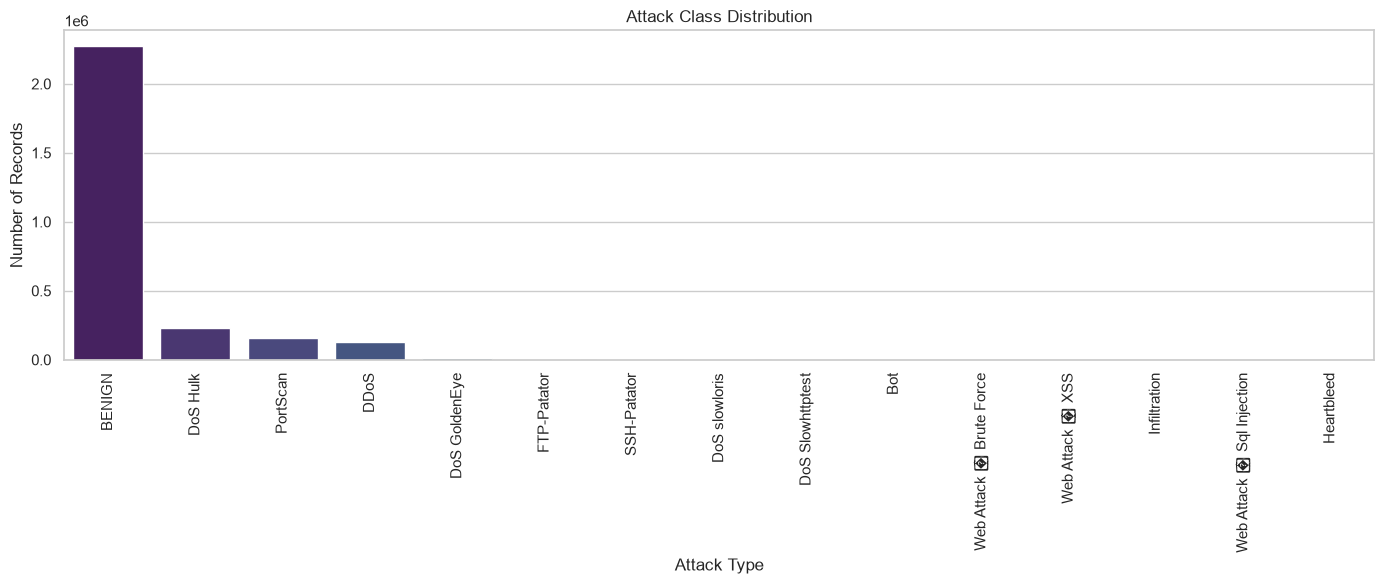

In [10]:
# =====================================================
# CLASS DISTRIBUTION VISUALIZATION
# =====================================================

plt.figure(figsize=(14,6))

sns.barplot(
    x=class_distribution.index,
    y=class_distribution.values,
    palette="viridis"
)

plt.xticks(rotation=90)
plt.title("Attack Class Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "attack_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# =====================================================
# BENIGN VS ATTACK
# =====================================================

binary_distribution = merged_df[label_column].apply(
    lambda x: "Benign" if str(x).strip().upper() == "BENIGN" else "Attack"
)

binary_distribution = binary_distribution.value_counts()

binary_distribution

 Label
Benign    2273097
Attack     557646
Name: count, dtype: int64

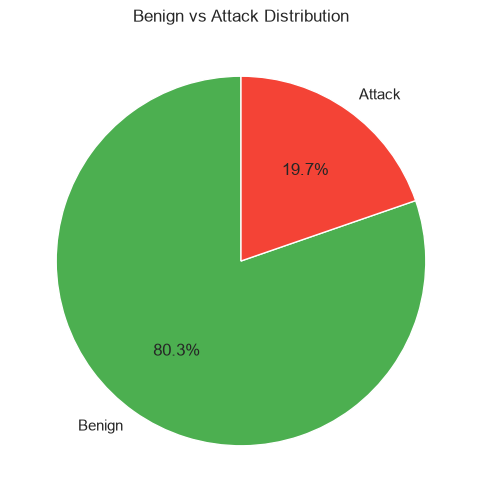

In [14]:
# =====================================================
# BENIGN VS ATTACK PIE CHART
# =====================================================

plt.figure(figsize=(6,6))

plt.pie(
    binary_distribution.values,
    labels=binary_distribution.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#F44336"]
)

plt.title("Benign vs Attack Distribution")

plt.savefig(
    FIGURES_PATH / "benign_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# =====================================================
# DATA TYPES
# =====================================================

dtype_summary = merged_df.dtypes.value_counts()

dtype_summary

int64      54
float64    24
str         1
Name: count, dtype: int64

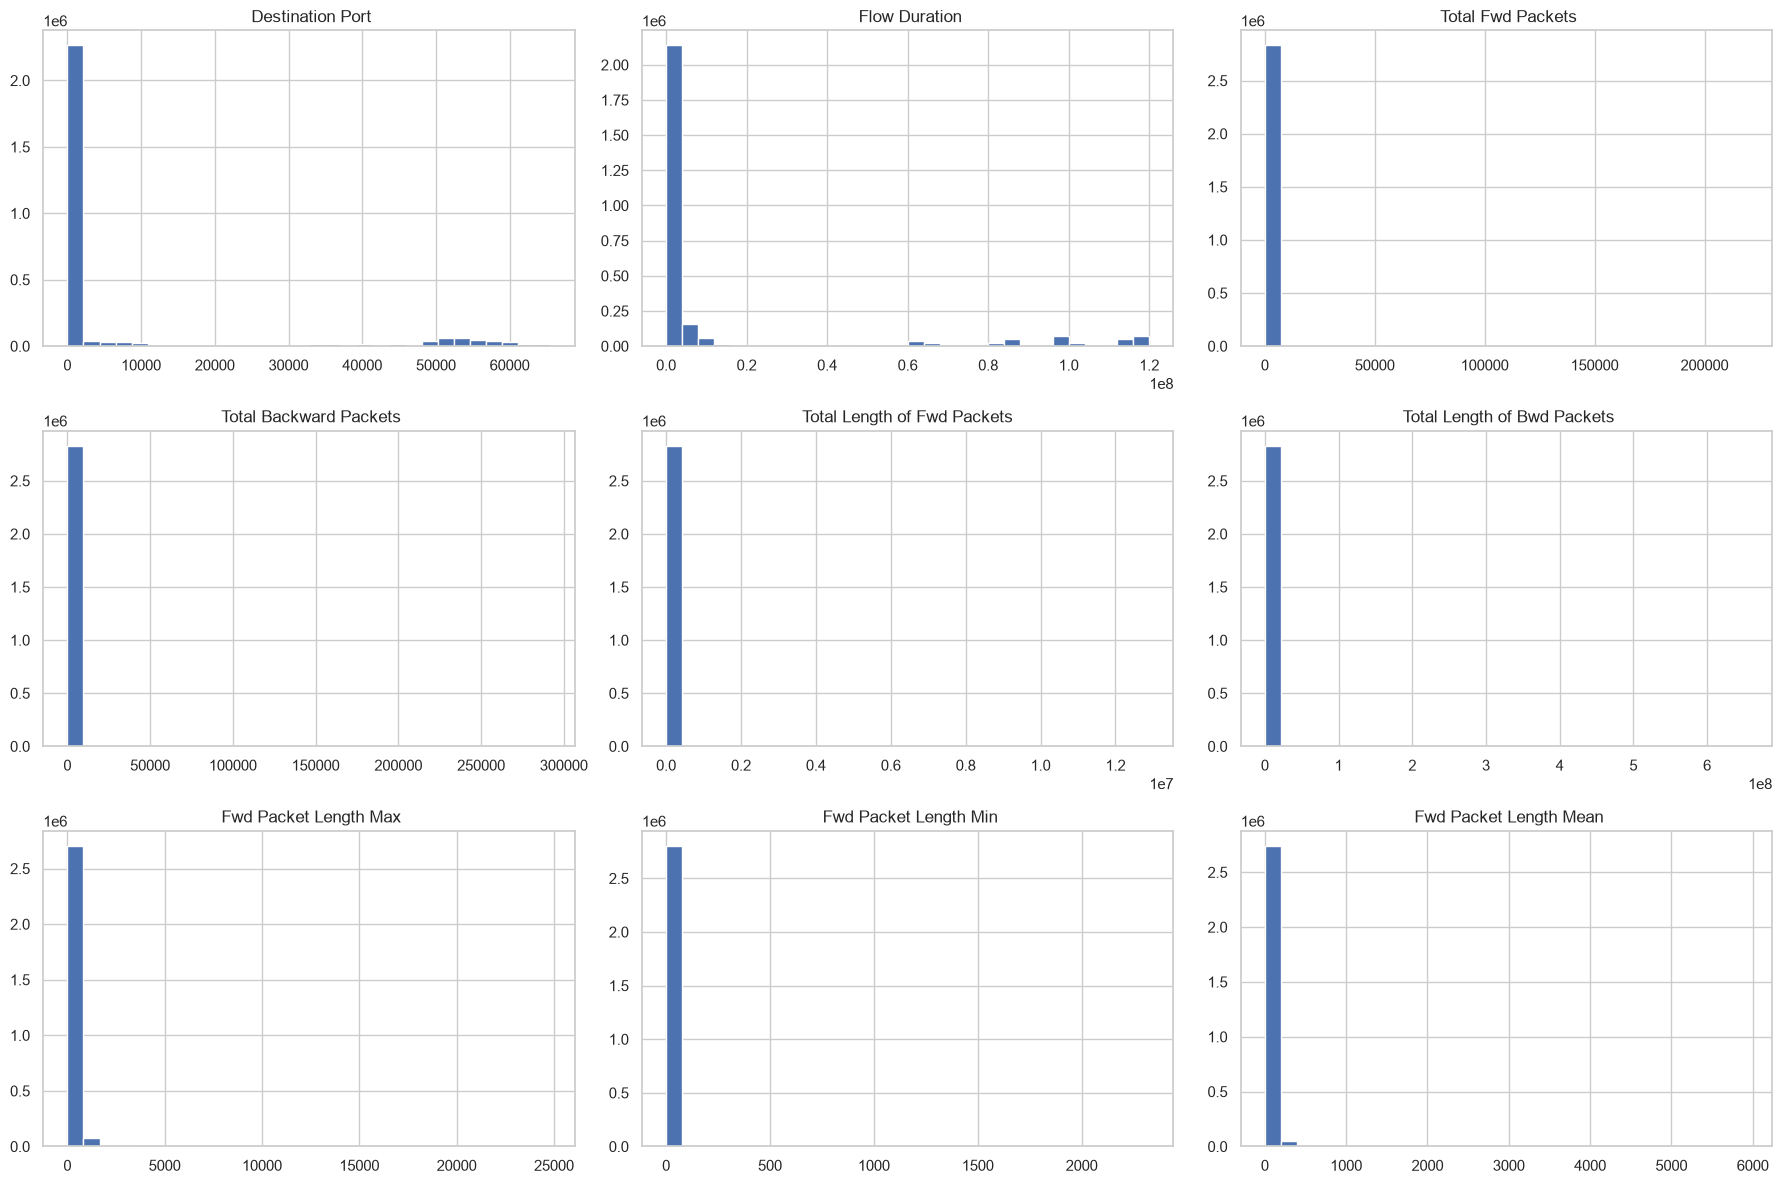

In [16]:
# =====================================================
# FEATURE DISTRIBUTION
# =====================================================

numeric_columns = merged_df.select_dtypes(include=np.number).columns

merged_df[numeric_columns[:9]].hist(
    figsize=(18, 12),
    bins=30
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "feature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

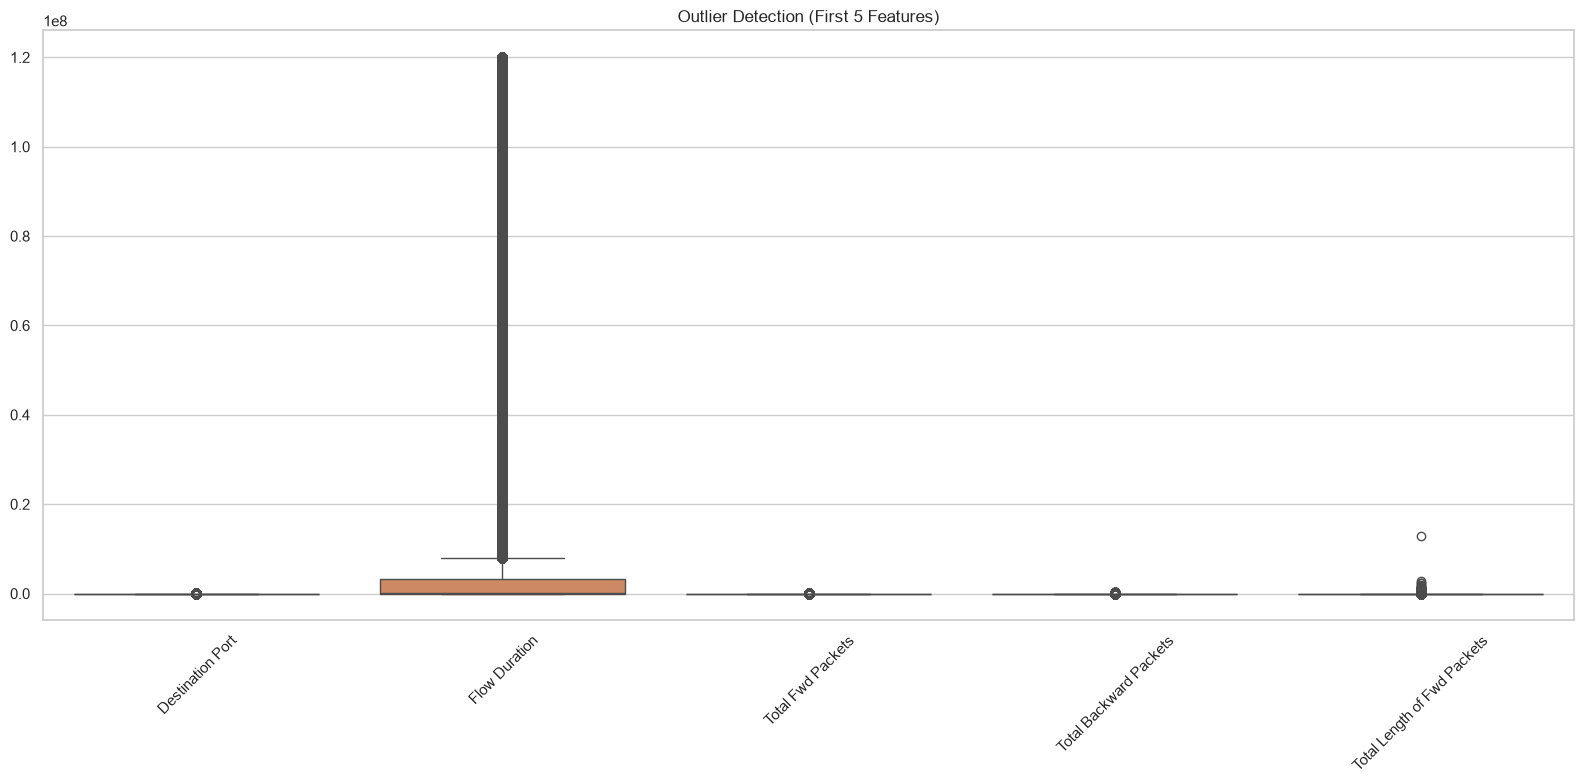

In [17]:
# =====================================================
# BOXPLOTS
# =====================================================

plt.figure(figsize=(16,8))

sns.boxplot(
    data=merged_df[numeric_columns[:5]]
)

plt.xticks(rotation=45)

plt.title("Outlier Detection (First 5 Features)")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

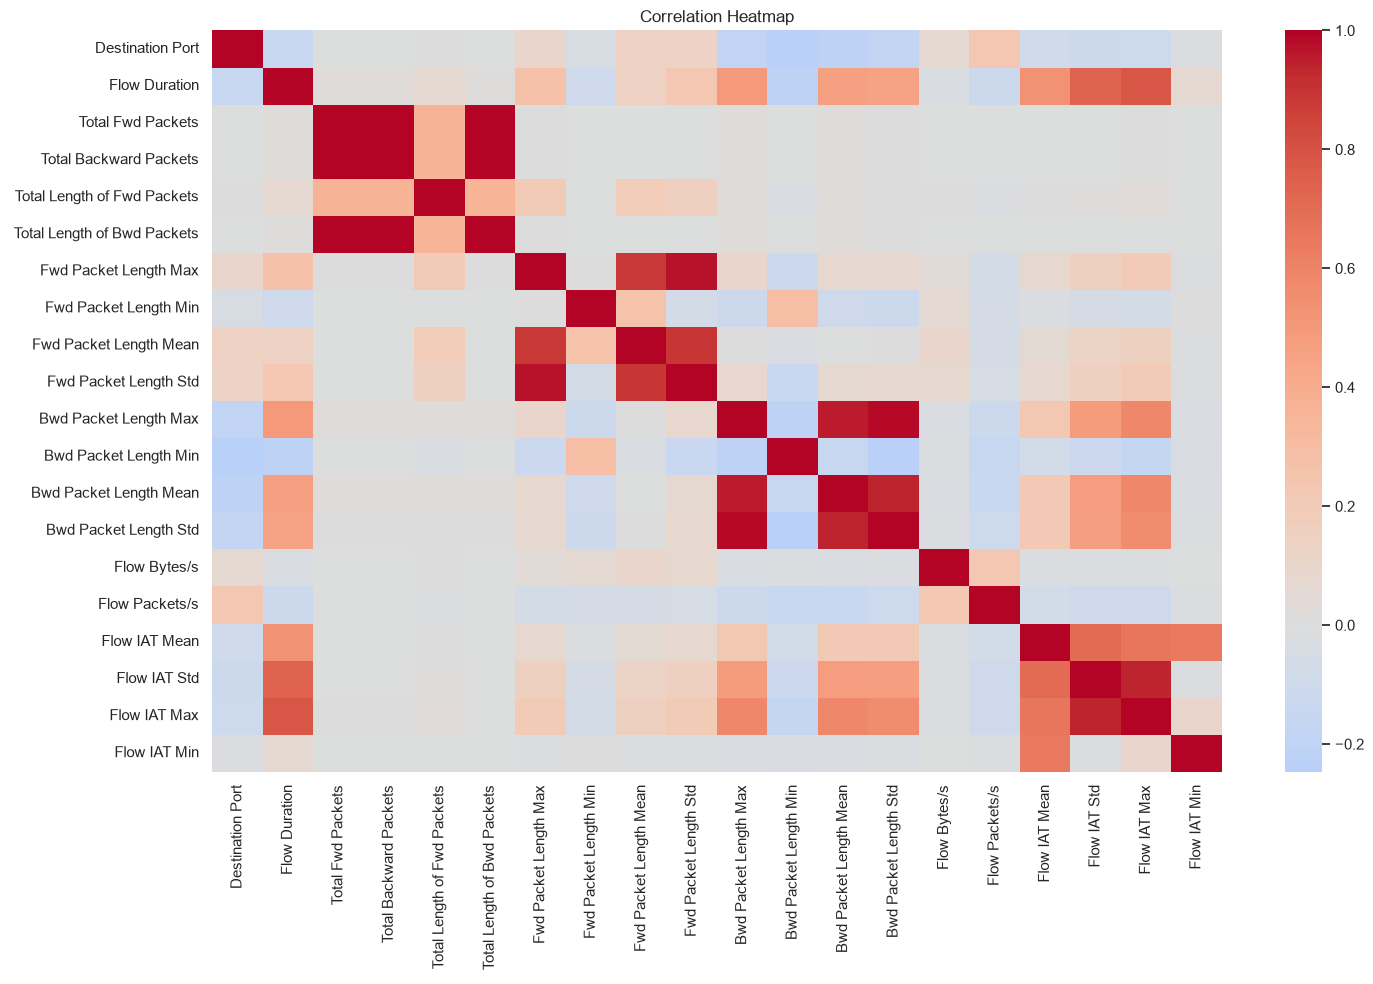

In [18]:
# =====================================================
# CORRELATION HEATMAP
# =====================================================

correlation = merged_df[numeric_columns[:20]].corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# =====================================================
# SAVE EDA SUMMARY
# =====================================================

eda_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Missing Values",
        "Attack Classes"
    ],
    "Value": [
        merged_df.shape[0],
        merged_df.shape[1],
        merged_df.duplicated().sum(),
        merged_df.isnull().sum().sum(),
        merged_df[label_column].nunique()
    ]
})

eda_summary.to_csv(
    RESULTS_PATH / "metrics" / "eda_summary.csv",
    index=False
)

eda_summary

,Metric,Value
0,Total Rows,2830743
1,Total Columns,79
2,Duplicate Rows,308381
3,Missing Values,1358
4,Attack Classes,15


# Findings

## Key Observations

- Successfully merged all 8 CICIDS2017 CSV files.
- Dataset contains approximately 3 million network flow records.
- Multiple attack categories are present.
- Dataset is highly imbalanced (BENIGN dominates).
- Some missing and duplicate values exist.
- Several features show strong correlations.
- Outliers are present and will be handled during preprocessing.

## Next Step

Notebook 03 - Data Preprocessing